# PoC: Clasificador canto de Aves (Iteración 0)

Alejandro Morales

The following is a detailed description of the fields of this object:

- gen: the generic name of the species
- sp: the specific name (epithet) of the species
- ssp: the subspecies name (subspecific epithet)
- grp: the group to which the species belongs (birds, grasshoppers, bats)
- type: the sound type of the recording (combining both predefined terms such as 'call' or 'song' and additional free text options)
- sex: the sex of the animal
- stage: the life stage of the animal (adult, juvenile, etc.)
- q: the current quality rating for the recording
- also: an array with the identified background species in the recording
- animal-seen: was the recorded animal seen?
- smp: sample rate
- method

## EDA

In [13]:
import pandas as pd
import os

In [14]:
import librosa
import librosa.display
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import numpy as np

In [15]:
def safe(fn):
    def wrapper(x):
        try:
            return fn(x)
        except Exception as e:
            return e  # o None, o (x, e)
    return wrapper

In [60]:
from mutagen.mp3 import MP3
db_path = "momota"
is_mp3 = lambda fn: fn.endswith(".mp3")
to_full_path = lambda filename: os.path.join(db_path, filename)
to_safe_mp3 = lambda fn: (fn, safe(MP3)(fn))
is_not_an_exception = lambda tuple: not isinstance(tuple[1], Exception)
extract_tags = lambda info: {"length": info.length, "sample_rate": info.sample_rate, "bitrate": info.bitrate, "channels":info.channels}
to_tags_of_interest = lambda tuple: (tuple[0], extract_tags(tuple[1].info))
to_consolided_dict = lambda tuple: {"filename": tuple[0].replace('momota/', ''), **tuple[1]}

metadata = list(
    map(to_consolided_dict,
        map(to_tags_of_interest,
            filter(is_not_an_exception,
                map(to_safe_mp3,
                    map(to_full_path,
                        filter(is_mp3, os.listdir(db_path))
                    )
                )
            )
        )
    )
)


In [61]:
df = pd.DataFrame(data=metadata)

In [62]:
df

,filename,length,sample_rate,bitrate,channels
0,XC525592_Momotus_momota.mp3,32.416050,44100,160000,2
1,XC532573_Momotus_momota.mp3,202.996600,44100,160000,2
2,XC520957_Momotus_momota.mp3,27.609050,44100,160000,2
3,XC54546_Momotus_momota.mp3,30.338062,44100,128000,1
4,XC152261_Momotus_momota.mp3,92.784542,44100,192000,2
5,XC520954_Momotus_momota.mp3,18.831650,44100,160000,2
6,XC525591_Momotus_momota.mp3,101.901600,44100,160000,2
7,XC127845_Momotus_momota.mp3,21.545750,44100,96000,1
8,XC245276_Momotus_momota.mp3,35.378937,48000,320000,1
9,XC520952_Momotus_momota.mp3,85.339450,44100,160000,2


In [21]:
df['sample_rate'].value_counts()


sample_rate
44100    28
48000     1
Name: count, dtype: int64

In [22]:
df['channels'].value_counts()

channels
2    24
1     5
Name: count, dtype: int64

In [23]:
import seaborn as sns

In [24]:
df['length'].mean()

np.float64(68.7756099137931)

<Axes: xlabel='length', ylabel='Count'>

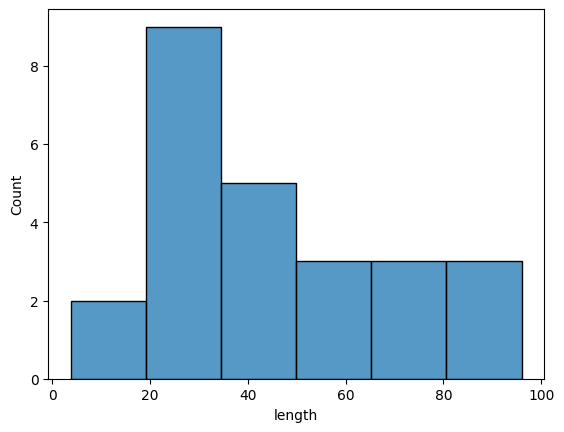

In [27]:
# hagamos zoom
sns.histplot(data=df.query("length < 100"), x='length')

In [51]:

def crear_espectrograma(y, sr_bio, n, hop_length, ruta_salida_img):
    
    stft = librosa.stft(y, n_fft=n, hop_length=hop_length)
    stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
    
    # 3. Graficar y guardar
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(stft_db, sr=sr_bio, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='viridis')
    
    #plt.axis("off")
    plt.colorbar(format='%+2.0f dB')
    plt.title('Espectrograma Lineal (Hz) - Canto de Ave')
    plt.tight_layout()
    plt.savefig(ruta_salida_img, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()


In [29]:
def crear_waveform(y, sr_bio, n, hop, ruta_salida_img):

    fig, ax1 = plt.subplots(figsize=(10, 4))

    librosa.display.waveshow(y, sr=sr_bio)
    ax1.set_ylabel("Waveform")

    rms = librosa.feature.rms(y=y, frame_length=n, hop_length=hop)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=n, hop_length=hop)[0]
    frames = range(len(rms))
    t = librosa.frames_to_time(frames, sr=sr_bio, hop_length=hop)

    ax2 = ax1.twinx()
    ax2.plot(t, rms, color="orange", label="RMS")
    ax2.plot(t, zcr, color="green", label="ZCR")
    ax2.set_ylabel("RMS / ZCR")
    ax2.legend(loc="upper right")

    #plt.axis("off")
    plt.tight_layout()
    plt.savefig(ruta_salida_img, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

    return t, rms, zcr

In [41]:
def feature_extraction(filename, sr, n, hop):
    espectrograma_filename = f"{filename}-espectrogram.png"
    waveform_filename = f"{filename}-waveform.png"
    y, sr = librosa.load(to_full_path(filename), sr=sr)
    crear_espectrograma( y, sr, n, hop, espectrograma_filename)
    t, rms, zcr = crear_waveform(y, sr, n, hop, waveform_filename)

    return {
        "y": y,
        "ymax": y.max(),
        "ymin": y.min(),
        "t": t,
        "rms": rms,
        "rms_mean": np.mean(rms),
        "zcr": zcr,
        "espectrograma_filename": espectrograma_filename,
        "waveform_filename": waveform_filename
    }

In [42]:
sr=44100

In [49]:
 # 1. Cargar el audio. 
n = 2048
hop = 512
filename = 'XC91898_Momotus_momota.mp3'

In [52]:
feature_extraction(filename, sr, n, hop)

{'y': array([ 0.0000000e+00,  1.0483762e-11, -1.9237233e-11, ...,
         3.6213582e-06,  1.5828437e-06,  8.5648335e-06],
       shape=(163584,), dtype=float32),
 'ymax': np.float32(0.0329214),
 'ymin': np.float32(-0.034916285),
 't': array([0.        , 0.01160998, 0.02321995, 0.03482993, 0.04643991,
        0.05804989, 0.06965986, 0.08126984, 0.09287982, 0.1044898 ,
        0.11609977, 0.12770975, 0.13931973, 0.15092971, 0.16253968,
        0.17414966, 0.18575964, 0.19736961, 0.20897959, 0.22058957,
        0.23219955, 0.24380952, 0.2554195 , 0.26702948, 0.27863946,
        0.29024943, 0.30185941, 0.31346939, 0.32507937, 0.33668934,
        0.34829932, 0.3599093 , 0.37151927, 0.38312925, 0.39473923,
        0.40634921, 0.41795918, 0.42956916, 0.44117914, 0.45278912,
        0.46439909, 0.47600907, 0.48761905, 0.49922902, 0.510839  ,
        0.52244898, 0.53405896, 0.54566893, 0.55727891, 0.56888889,
        0.58049887, 0.59210884, 0.60371882, 0.6153288 , 0.62693878,
        0.6385487

In [44]:
%ls

__pycache__/       download.py        momota/
download.ipynb     iteracion_0.ipynb


In [ ]:
# TODO, definir una heuristica para audio activity detection
# TODO: normalizar canales

In [63]:
df.apply(lambda row: feature_extraction(row['filename'], row['sample_rate'], n, hop), axis=1)

0     {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
1     {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
2     {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
3     {'y': [0.0, 8.0062845e-11, 9.394287e-11, 4.706...
4     {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
5     {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
6     {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
7     {'y': [0.0, 2.4120532e-11, 1.6474523e-11, 1.00...
8     {'y': [-5.608933e-06, 5.10871e-06, 2.6019217e-...
9     {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
10    {'y': [0.0, -5.099137e-13, -5.040367e-14, 2.92...
11    {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
12    {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
13    {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
14    {'y': [0.0, 1.0483762e-11, -1.9237233e-11, -2....
15    {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
16    {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
17    {'y': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

In [ ]:
# Interesante: XC245276_Momotus_momota.mp3-espectrogram

In [64]:
filename = '/Users/alejandromorales/ws/bayesian_explorations/notebooks/sintetizador_canto_aves/xc273644-momoto-serrano-momotus-aequatorialis.mp3'

In [65]:
feature_extraction(filename, sr, n, hop)

{'y': array([ 0.0000000e+00,  1.0270756e-14, -8.6840832e-13, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       shape=(1300608,), dtype=float32),
 'ymax': np.float32(0.59092915),
 'ymin': np.float32(-0.57084274),
 't': array([0.00000000e+00, 1.16099773e-02, 2.32199546e-02, ...,
        2.94661224e+01, 2.94777324e+01, 2.94893424e+01], shape=(2541,)),
 'rms': array([1.2085117e-06, 7.4971208e-06, 1.0415410e-05, ..., 8.7304707e-06,
        1.2978520e-06, 2.5319417e-07], shape=(2541,), dtype=float32),
 'rms_mean': np.float32(0.025382565),
 'zcr': array([0.25292969, 0.39697266, 0.51513672, ..., 0.40283203, 0.28271484,
        0.12646484], shape=(2541,)),
 'espectrograma_filename': '/Users/alejandromorales/ws/bayesian_explorations/notebooks/sintetizador_canto_aves/xc273644-momoto-serrano-momotus-aequatorialis.mp3-espectrogram.png',
 'waveform_filename': '/Users/alejandromorales/ws/bayesian_explorations/notebooks/sintetizador_canto_aves/xc273644-momoto-serrano-momotus-aequato